# 🔬 Notebook 1: Exploratory Data Analysis
**Smoking Status Prediction — Health Checkup Dataset**

This notebook explores the dataset deeply through univariate, bivariate, and multivariate analysis. The goal is to understand the data before modeling.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os
warnings.filterwarnings('ignore')

# Create plots directory if it doesn't exist
os.makedirs('plots', exist_ok=True)

# Consistent style for all plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13

RANDOM_STATE = 42

## 1. Load Data & Basic Overview

> **What we do:** Load the dataset and get a quick feel for its shape, types, and completeness.

In [2]:
# Load sample data (300 rows generated by generate_data.py)
# Replace path if running on your own machine
df = pd.read_csv('your_data.csv')

# Drop ID column — it's just a row index, not a real feature
df.drop(columns=['id'], inplace=True, errors='ignore')

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names:\n{df.columns.tolist()}")


Shape: 159256 rows × 12 columns

Column names:
['Unnamed: 0', 'Cholesterol', 'triglyceride', 'age', 'hearing(right)', 'hemoglobin', 'LDL', 'dental caries', 'systolic', 'hearing(left)', 'eyesight(left)', 'smoking']


In [3]:
# ── Data types ───────────────────────────────────────────────────────────────
print("Data Types:")
print(df.dtypes)


Data Types:
Unnamed: 0          int64
Cholesterol         int64
triglyceride        int64
age                 int64
hearing(right)      int64
hemoglobin        float64
LDL                 int64
dental caries       int64
systolic            int64
hearing(left)       int64
eyesight(left)    float64
smoking             int64
dtype: object


In [4]:
# ── Missing values ───────────────────────────────────────────────────────────
missing = df.isnull().sum()
print("Missing Values per Column:")
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values found!")


Missing Values per Column:
✅ No missing values found!


In [5]:
# ── Duplicate rows ───────────────────────────────────────────────────────────
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f"Dropped duplicates. New shape: {df.shape}")


Duplicate rows: 0


In [6]:
# ── Statistical summary ──────────────────────────────────────────────────────
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,159256.0,79627.50,45973.39,0.0,39813.75,79627.5,119441.25,159255.0
Cholesterol,159256.0,195.80,28.40,77.0,175.00,196.0,217.00,393.0
triglyceride,159256.0,127.62,66.19,8.0,77.00,115.0,165.00,766.0
age,159256.0,44.31,11.84,20.0,40.00,40.0,55.00,85.0
hearing(right),159256.0,1.02,0.15,1.0,1.00,1.0,1.00,2.0
hemoglobin,159256.0,14.80,1.43,4.9,13.80,15.0,15.80,21.0
LDL,159256.0,114.61,28.16,1.0,95.00,114.0,133.00,1860.0
dental caries,159256.0,0.20,0.40,0.0,0.00,0.0,0.00,1.0
systolic,159256.0,122.50,12.73,77.0,114.00,121.0,130.00,213.0
hearing(left),159256.0,1.02,0.15,1.0,1.00,1.0,1.00,2.0


## 2. Target Variable: `smoking`

> The target column tells us whether a person smokes (1) or not (0). Understanding its balance is crucial — imbalanced classes can trick a model into always predicting the majority class.

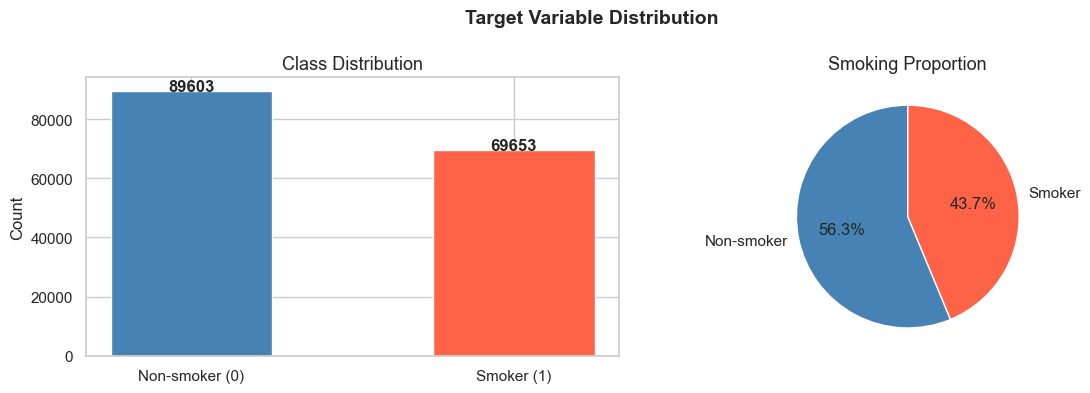


Class balance:
smoking
0    89603
1    69653
Name: count, dtype: int64

Smoking rate: 43.7%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['smoking'].value_counts()
axes[0].bar(['Non-smoker (0)', 'Smoker (1)'], counts.values, color=['steelblue', 'tomato'], width=0.5)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Non-smoker', 'Smoker'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Smoking Proportion')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/target_distribution.png', bbox_inches='tight')
plt.show()

print(f"\nClass balance:\n{counts}")
print(f"\nSmoking rate: {counts[1]/len(df)*100:.1f}%")


> **Insight:** The dataset is **not** reasonably balanced (~44% smokers, ~56% non-smokers). special class-weighting is needed and we should still track precision/recall for both classes.

## 3. Column Explanations

Before analysis, let's understand what each feature means:

| Feature | Meaning |
|---|---|
| `age` | Age in years |
| `eyesight(left)` | Visual acuity (higher = better) |
| `hearing(left/right)` | Hearing test result (1=normal, 2=abnormal) |
| `systolic` | Systolic blood pressure (top number) |
| `Cholesterol` | Total cholesterol level |
| `triglyceride` | Blood fat level |
| `LDL` | 'Bad' cholesterol |
| `hemoglobin` | Oxygen-carrying protein in blood |
| `dental caries` | Presence of tooth decay (0=no, 1=yes) |
| `smoking` | **TARGET**: 1=smoker, 0=non-smoker |

## 4. Univariate Analysis

> **What:** Look at each feature individually.
> **Why:** To understand its distribution, spot outliers, and detect skewness.

In [8]:
import os
os.makedirs('plots', exist_ok=True)

numerical_cols = df.select_dtypes(include=np.number).columns.drop('smoking').tolist()
print(f"Numerical features ({len(numerical_cols)}):")
print(numerical_cols)


Numerical features (11):
['Unnamed: 0', 'Cholesterol', 'triglyceride', 'age', 'hearing(right)', 'hemoglobin', 'LDL', 'dental caries', 'systolic', 'hearing(left)', 'eyesight(left)']


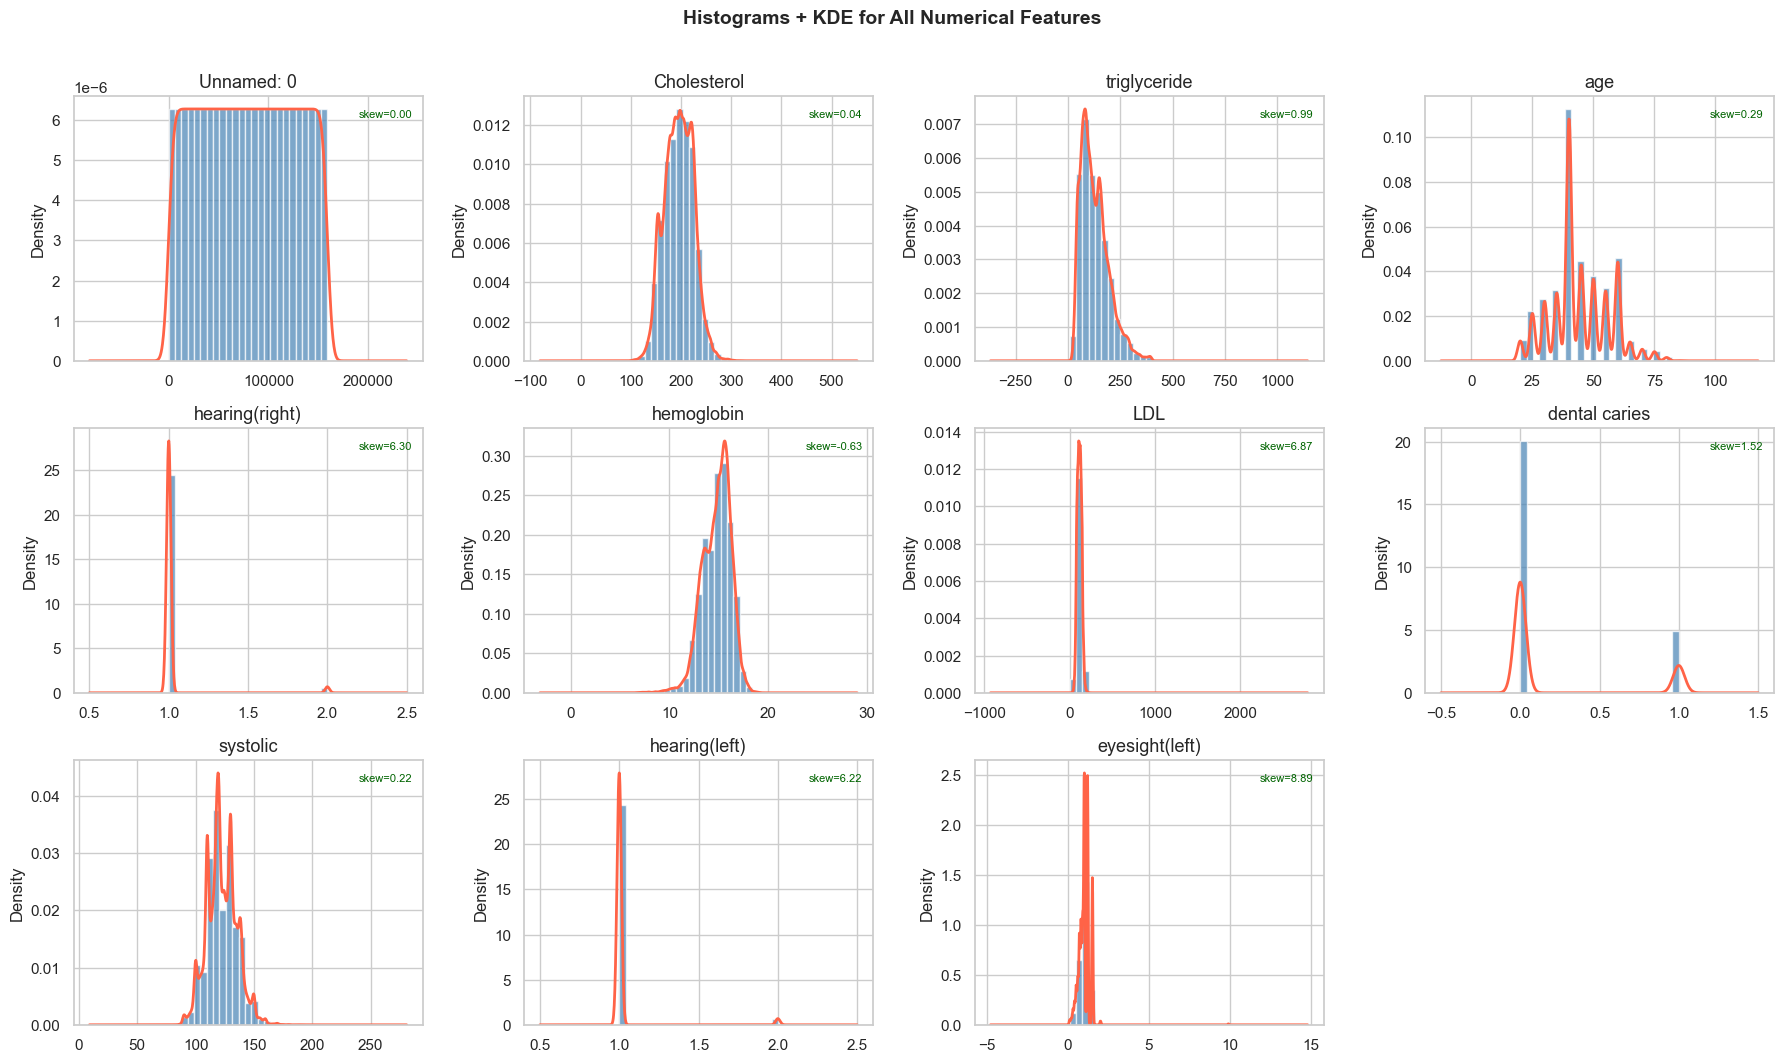

In [9]:
# ── Histograms + KDE for all numerical features ──────────────────────────────
n_cols = 4
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='white', alpha=0.7, density=True)
    df[col].plot.kde(ax=axes[i], color='tomato', linewidth=2)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    skew = df[col].skew()
    axes[i].text(0.97, 0.92, f'skew={skew:.2f}', transform=axes[i].transAxes,
                 ha='right', fontsize=8, color='darkgreen')

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histograms + KDE for All Numerical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/histograms_kde.png', bbox_inches='tight')
plt.show()

> **Insight:** Several features like `triglyceride`, `AST`, `ALT`, and `Gtp` show heavy right-skew, meaning most values are low but a few are extremely high. These will need outlier handling or log-transformation before modeling.

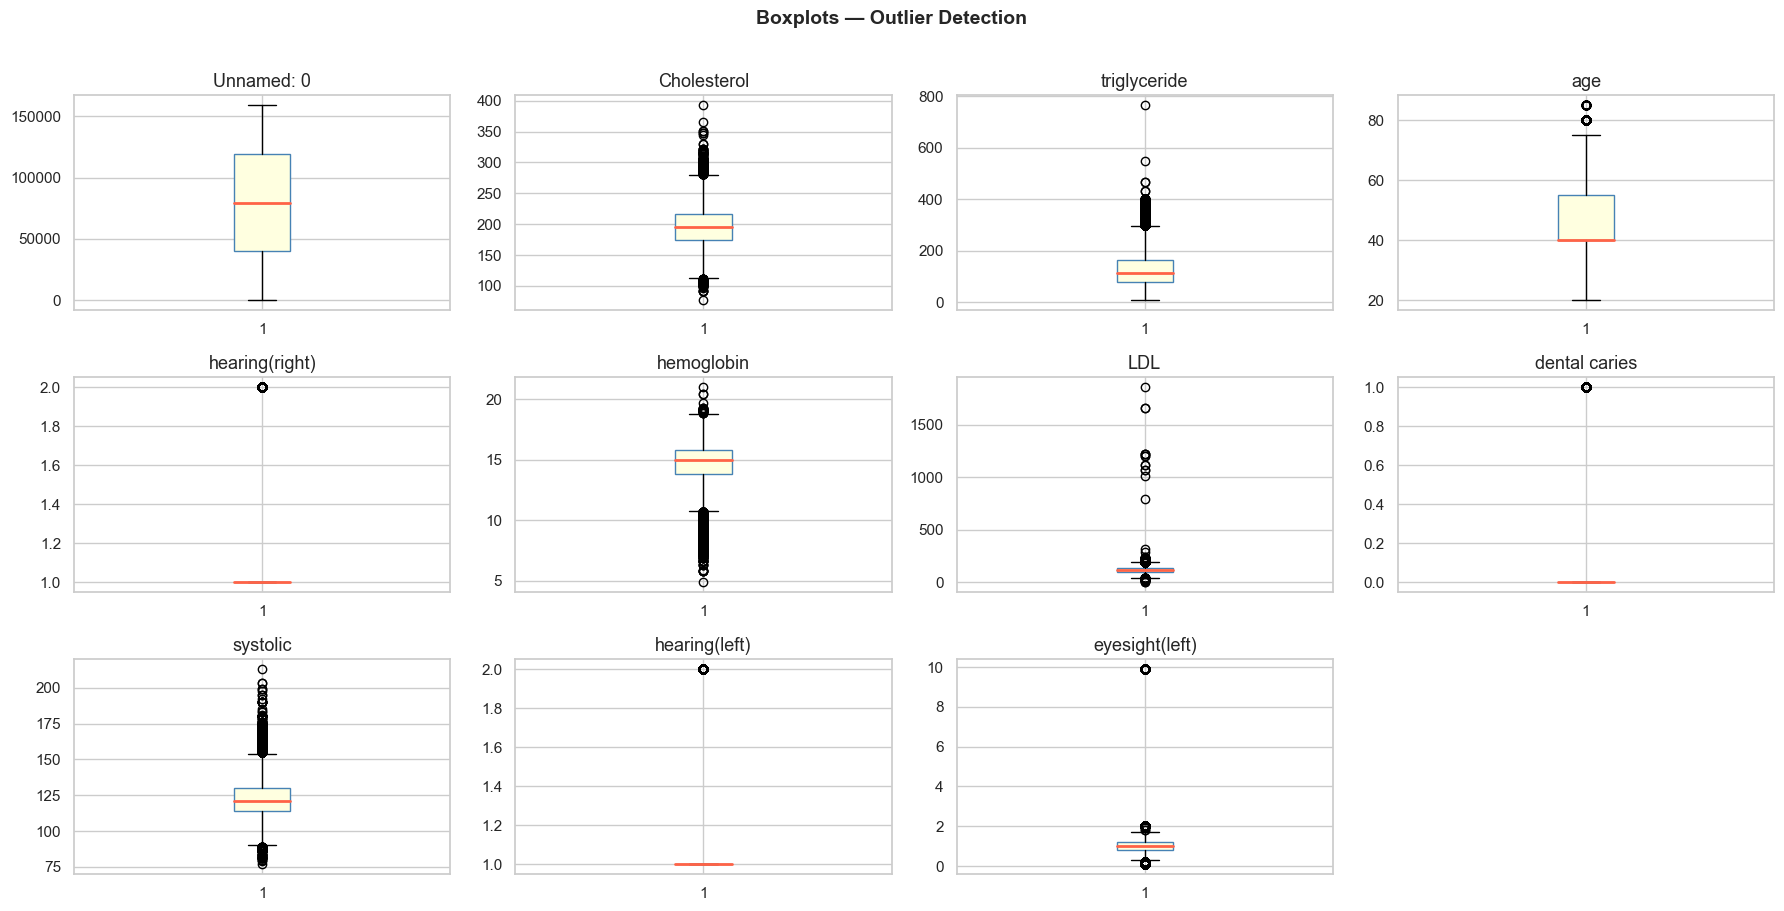

In [10]:
# ── Boxplots for outlier detection ───────────────────────────────────────────
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightyellow', color='steelblue'),
                    medianprops=dict(color='tomato', linewidth=2))
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Outlier Detection', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/boxplots.png', bbox_inches='tight')
plt.show()


In [11]:
# ── Skewness table ───────────────────────────────────────────────────────────
skewness = df[numerical_cols].skew().sort_values(ascending=False)
print("Skewness of features:")
print(skewness.round(3))
print("\nHighly skewed (|skew| > 1):")
print(skewness[abs(skewness) > 1].round(3))


Skewness of features:
eyesight(left)    8.891
LDL               6.875
hearing(right)    6.302
hearing(left)     6.224
dental caries     1.516
triglyceride      0.986
age               0.292
systolic          0.220
Cholesterol       0.043
Unnamed: 0        0.000
hemoglobin       -0.634
dtype: float64

Highly skewed (|skew| > 1):
eyesight(left)    8.891
LDL               6.875
hearing(right)    6.302
hearing(left)     6.224
dental caries     1.516
dtype: float64


> **Skewness Rule of Thumb:** |skew| < 0.5 = normal, 0.5–1 = moderate, > 1 = highly skewed.

## 5. Bivariate Analysis: Feature vs. Target

> **What:** Compare each feature between smokers and non-smokers.
> **Why:** To identify which features have the most predictive power.

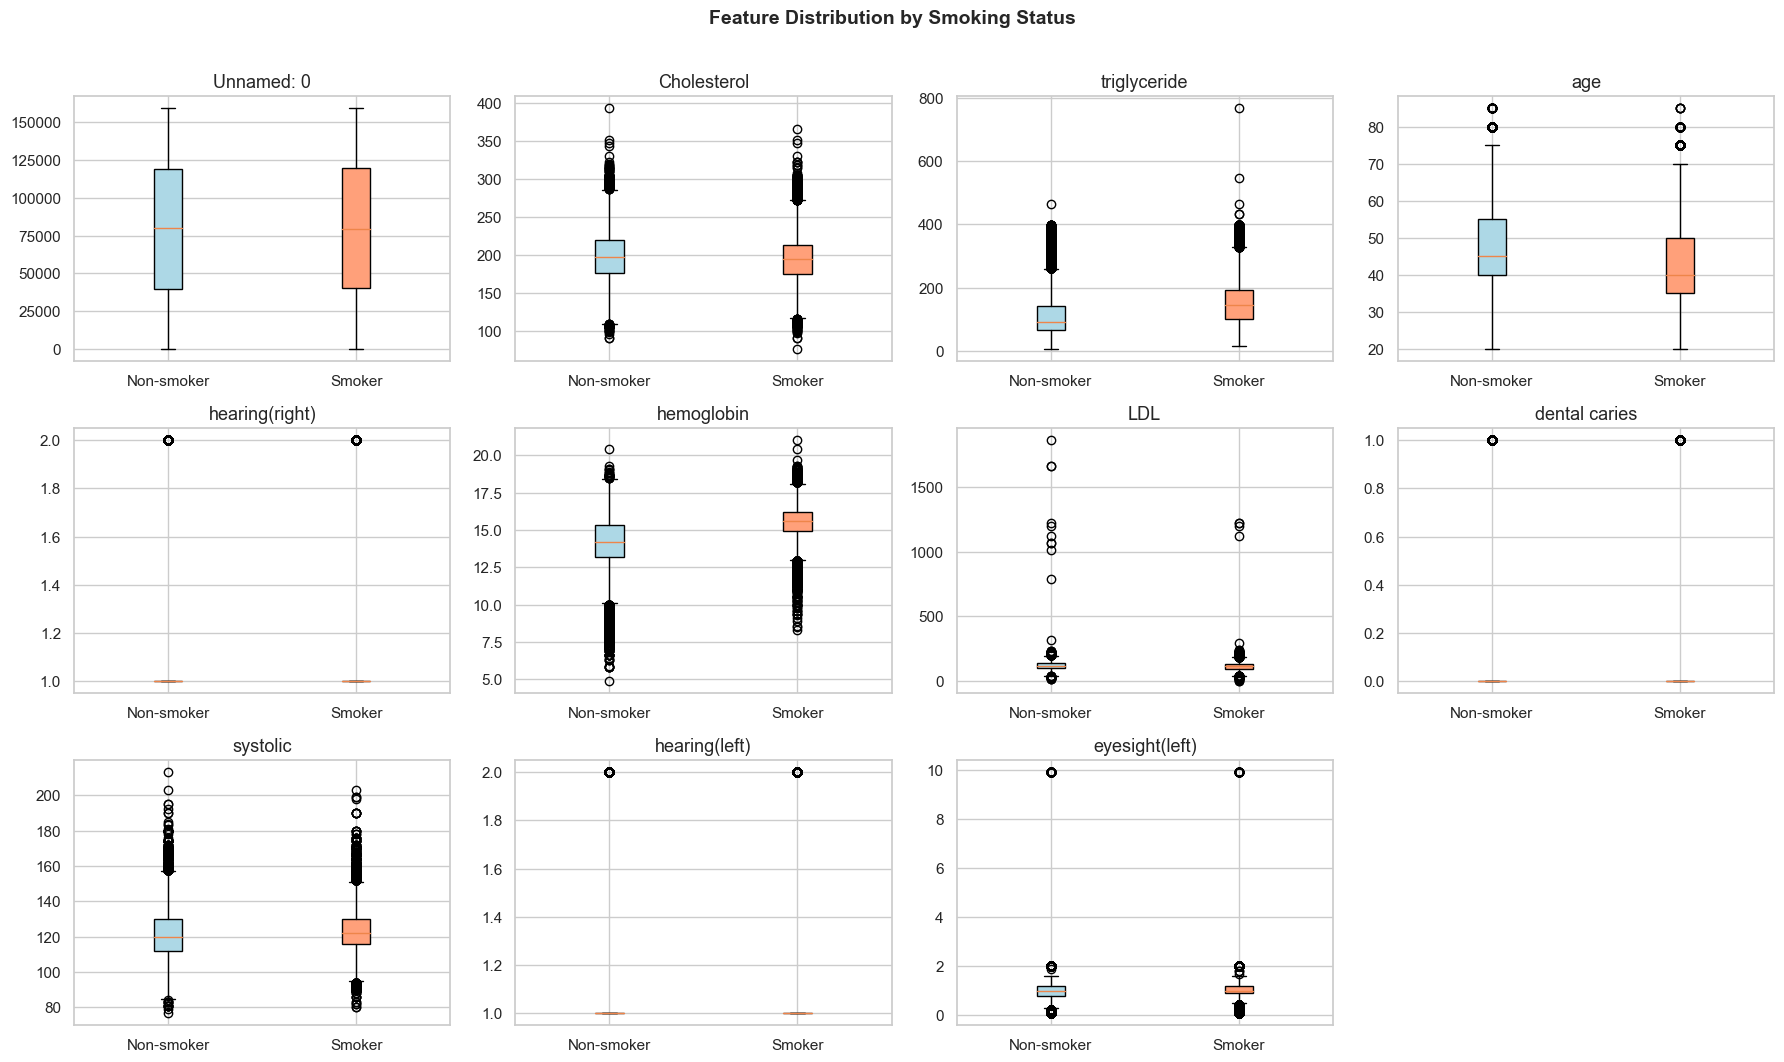

In [12]:
# ── Boxplots grouped by smoking status ───────────────────────────────────────
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

palette = {0: 'steelblue', 1: 'tomato'}
for i, col in enumerate(numerical_cols):
    groups = [df[df['smoking'] == 0][col], df[df['smoking'] == 1][col]]
    bp = axes[i].boxplot(groups, labels=['Non-smoker', 'Smoker'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightsalmon')
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distribution by Smoking Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/bivariate_boxplots.png', bbox_inches='tight')
plt.show()


In [13]:
# ── Mean comparison: smokers vs non-smokers ───────────────────────────────────
means = df.groupby('smoking')[numerical_cols].mean().T
means.columns = ['Non-smoker', 'Smoker']
means['Difference (%)'] = ((means['Smoker'] - means['Non-smoker']) / means['Non-smoker'] * 100).round(1)
means = means.sort_values('Difference (%)', key=abs, ascending=False)
print("Feature Means by Smoking Status:")
print(means.round(2).to_string())


Feature Means by Smoking Status:
                Non-smoker    Smoker  Difference (%)
dental caries         0.16      0.25            53.4
triglyceride        108.24    152.54            40.9
age                  46.46     41.54           -10.6
hemoglobin           14.23     15.53             9.1
eyesight(left)        0.97      1.05             8.4
LDL                 116.40    112.30            -3.5
Cholesterol         197.10    194.12            -1.5
systolic            121.85    123.35             1.2
hearing(right)        1.03      1.02            -1.1
hearing(left)         1.03      1.02            -1.1
Unnamed: 0        79653.10  79594.57            -0.1


> **Insight:** Smokers tend to have higher `hemoglobin`, `Gtp`, `triglyceride`, and `ALT` — all markers associated with smoking-related metabolic effects. Non-smokers tend to have higher `HDL` (good cholesterol), consistent with medical literature.

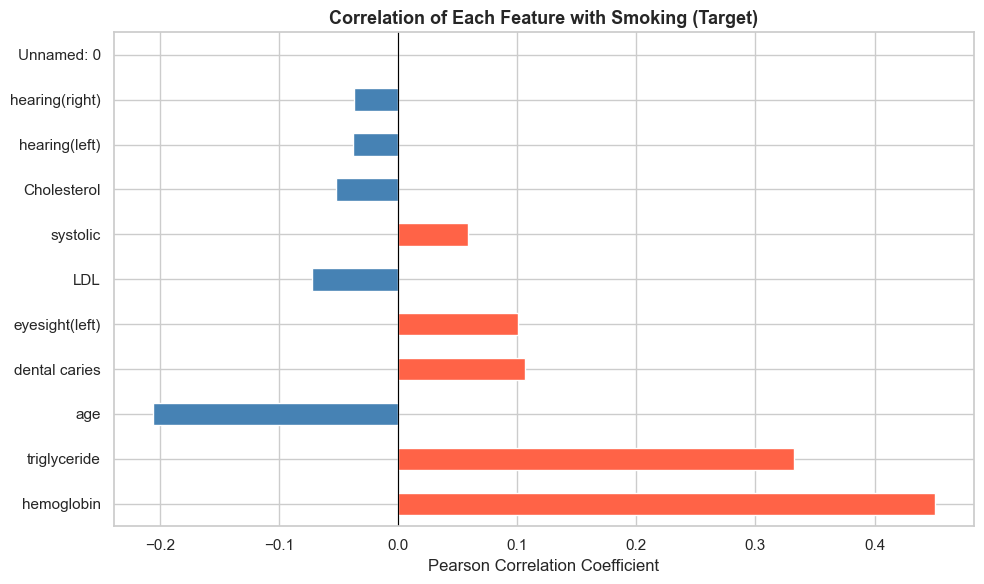


Top 5 most correlated with smoking:
hemoglobin        0.451
triglyceride      0.332
age              -0.206
dental caries     0.107
eyesight(left)    0.100
Name: smoking, dtype: float64


In [14]:
# ── Correlation of each feature with the target ───────────────────────────────
corr_with_target = df.corr(numeric_only=True)['smoking'].drop('smoking').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['tomato' if v > 0 else 'steelblue' for v in corr_with_target.values]
corr_with_target.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of Each Feature with Smoking (Target)', fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('plots/feature_target_correlation.png', bbox_inches='tight')
plt.show()

print("\nTop 5 most correlated with smoking:")
print(corr_with_target.head(5).round(3))


## 6. Multivariate Analysis

> **What:** Look at relationships between multiple features at once.
> **Why:** Helps detect multicollinearity (two features saying the same thing) and feature interactions.

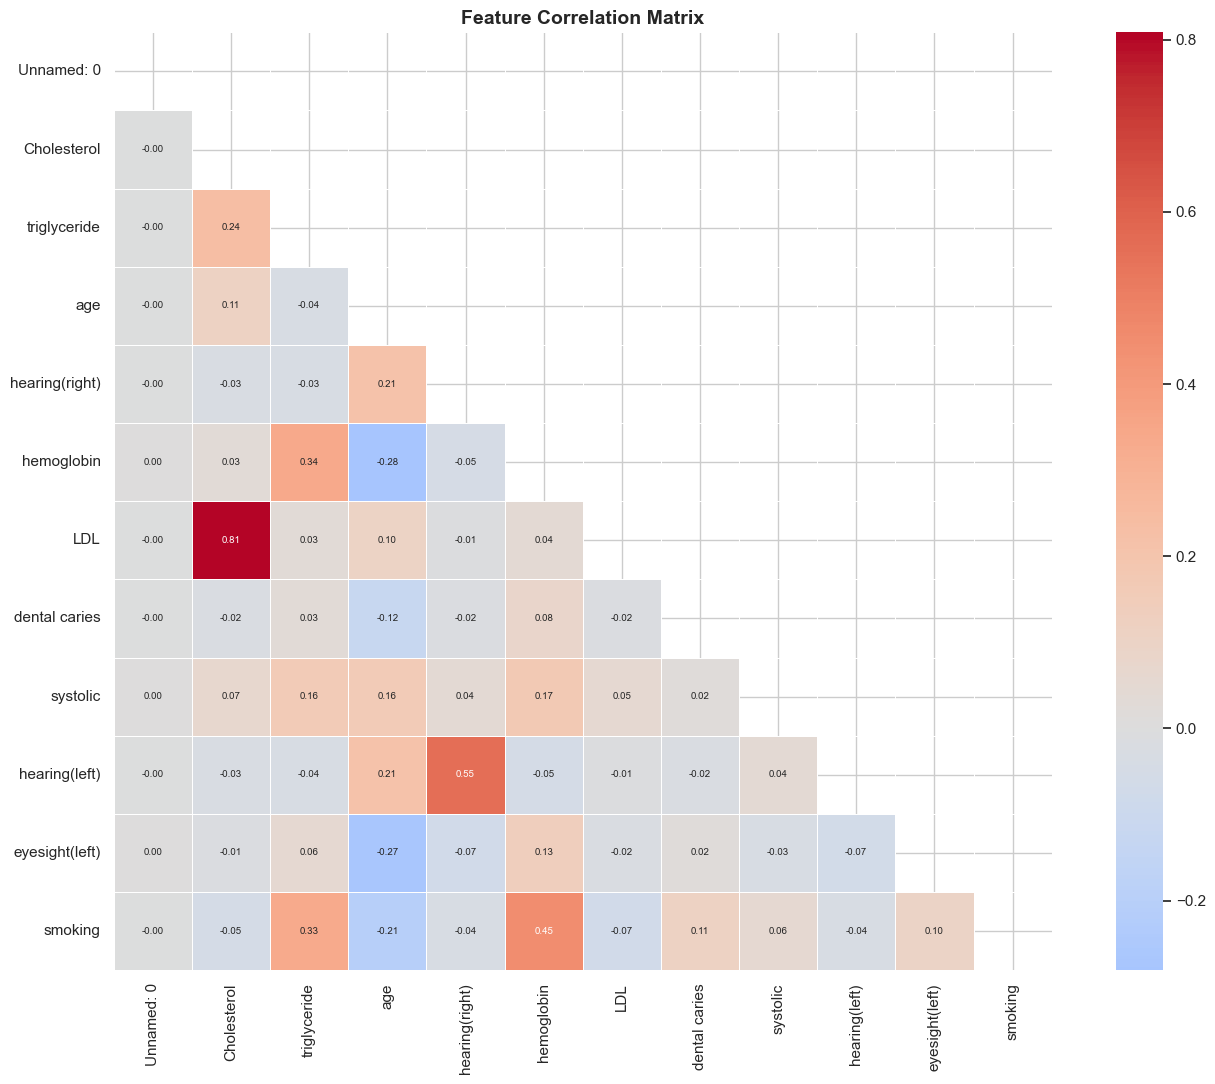

In [15]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(14, 11))
corr_matrix = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show only lower triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', bbox_inches='tight')
plt.show()


> **Multicollinearity Alert:**
> - `systolic` & `relaxation` are highly correlated (both are blood pressure measures).
> - `height` & `weight` are correlated with `waist`.
> - `AST` & `ALT` (both liver enzymes) are correlated.
> We may need to drop one from each pair, or use regularization in models.

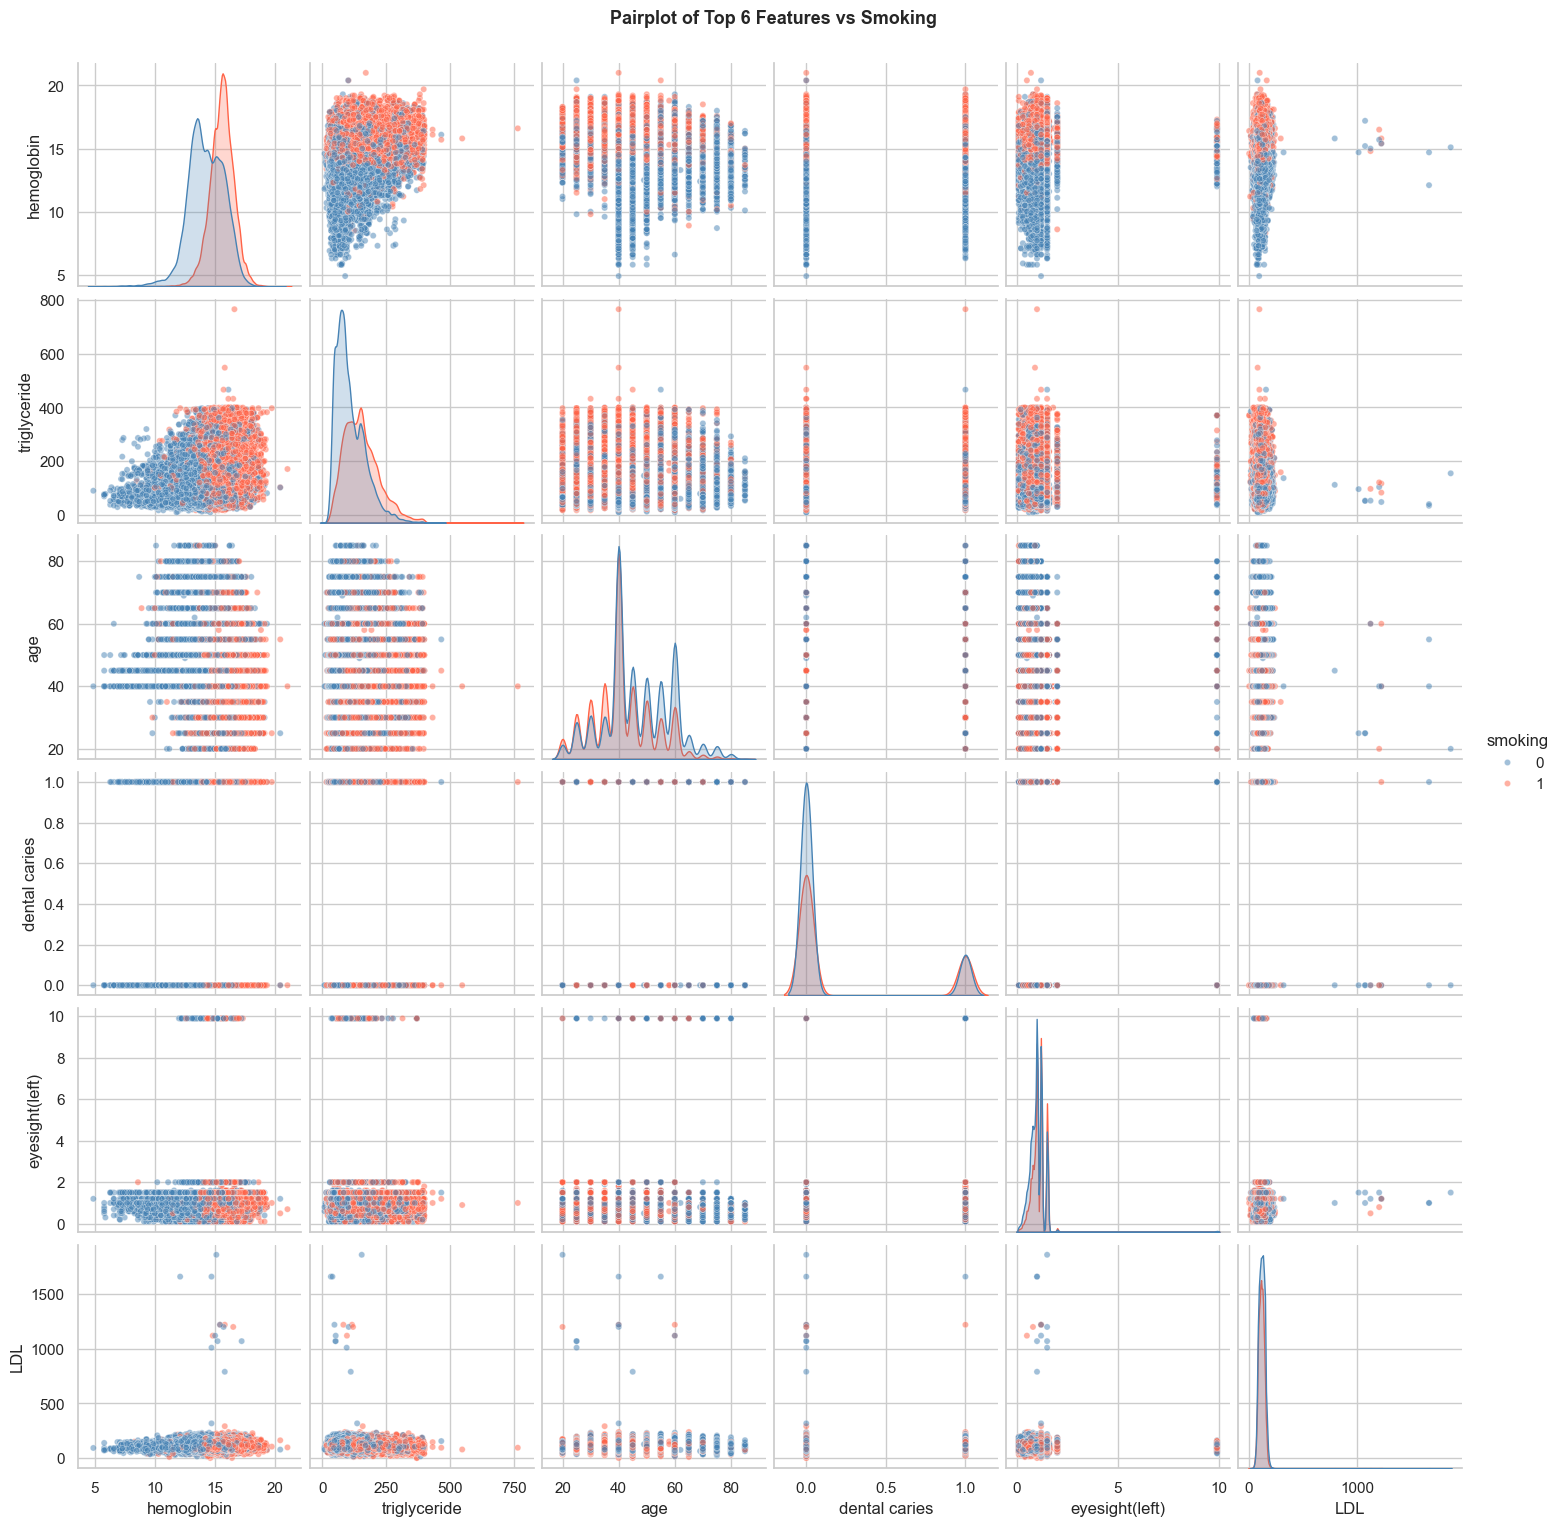

In [16]:
# ── Pairplot for top 6 most correlated features ──────────────────────────────
top_features = corr_with_target.head(6).index.tolist() + ['smoking']
pair_df = df[top_features].copy()

g = sns.pairplot(pair_df, hue='smoking', palette={0: 'steelblue', 1: 'tomato'},
                 diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})
g.fig.suptitle('Pairplot of Top 6 Features vs Smoking', y=1.02, fontsize=13, fontweight='bold')
plt.savefig('plots/pairplot.png', bbox_inches='tight')
plt.show()


## 7. Outlier Summary

> Using the IQR method to count outliers per feature.

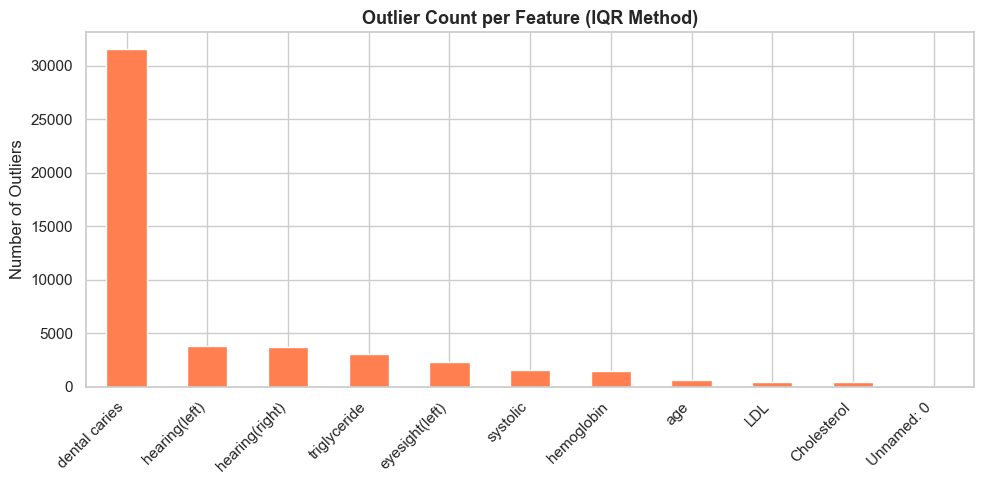

dental caries     31532
hearing(left)      3818
hearing(right)     3730
triglyceride       3087
eyesight(left)     2324
systolic           1592
hemoglobin         1493
age                 682
LDL                 495
Cholesterol         430
Unnamed: 0            0
dtype: int64


In [17]:
def count_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()

outlier_counts = pd.Series({col: count_outliers_iqr(df[col]) for col in numerical_cols})
outlier_counts = outlier_counts.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
outlier_counts.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Outlier Count per Feature (IQR Method)', fontweight='bold')
plt.ylabel('Number of Outliers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plots/outlier_counts.png', bbox_inches='tight')
plt.show()
print(outlier_counts)


## 8. Exploratory Summary

**Key findings from EDA:**
1. Dataset is **NOT** well-balanced (~44% smokers) — mild class imbalance.
2. No missing values — great, no imputation needed.
3. Skewed features: `eyesight(left)`,`LDL` (very high),`hearing(right)`    (very high),`hearing(left)`(very high),`dental caries`(high),`triglyceride`(high)
4. Top predictors of smoking: `hemoglobin`,`triglyceride`,`age`,`dental caries`,`eyesight(left)`  
6. Outliers are present dental carie heavily followed by hearing and tryiglecride